In [1]:
!pip install -q timm scikit-learn pandas


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import timm

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
root_dir = "/workspace/dataset_with_augmentation"   
splits = ["train", "val", "test"]

total_removed = 0

for split in splits:
    split_path = os.path.join(root_dir, split)
    print(f"\nCleaning {split.upper()}...")

    removed = 0
    before = 0

    for class_folder in os.listdir(split_path):
        class_path = os.path.join(split_path, class_folder)
        if not os.path.isdir(class_path):
            continue

        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)
            before += 1

            # Remove hidden
            if file.startswith("."):
                os.remove(file_path)
                removed += 1
                continue

            # Remove empty
            if os.path.getsize(file_path) == 0:
                os.remove(file_path)
                removed += 1
                continue

            # Remove corrupted
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except:
                os.remove(file_path)
                removed += 1

    total_removed += removed
    print(f"Files removed in {split}: {removed}")

print("\nTotal removed:", total_removed)
print("Dataset fully cleaned ✅")


Cleaning TRAIN...
Files removed in train: 0

Cleaning VAL...
Files removed in val: 0

Cleaning TEST...
Files removed in test: 0

Total removed: 0
Dataset fully cleaned ✅


In [4]:
class CustomGroupedDataset(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)

        new_samples = []
        new_targets = []

        for path, target in self.samples:
            folder_name = path.split(os.sep)[-2]
            class_id = int(folder_name.split(".")[0])

            if 1 <= class_id <= 3:
                new_label = class_id - 1
            elif 5 <= class_id <= 18:
                new_label = class_id - 2
            elif class_id == 21:
                new_label = 17
            elif 22 <= class_id <= 31:
                new_label = 18
            else:
                continue

            new_samples.append((path, new_label))
            new_targets.append(new_label)

        self.samples = new_samples
        self.targets = new_targets
        self.classes = [f"class_{i}" for i in range(21)]

In [7]:
IMAGE_SIZE = 224
BATCH_SIZE = 64   # Ada 4000 can handle this
NUM_WORKERS = 8

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = CustomGroupedDataset("dataset_with_augmentation/train", transform=train_transform)
val_dataset   = CustomGroupedDataset("dataset_with_augmentation/val", transform=val_transform)
test_dataset  = CustomGroupedDataset("dataset/test", transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Total Classes:", 21)
print("Train size:", len(train_dataset))

Total Classes: 21
Train size: 28466


In [8]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=21
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

# Mixed Precision (AMP)
scaler = torch.cuda.amp.GradScaler()

print("Model ready ✅")

Model ready ✅


/tmp/ipykernel_13163/1216949487.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [9]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    cm = confusion_matrix(all_labels, all_preds)

    return acc, cm

In [10]:
EPOCHS = 50
PATIENCE = 7   # stop if no improvement for 7 validations

best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    # ---- Validate every 5 epochs ----
    if (epoch + 1) % 5 == 0:

        val_acc, cm = evaluate(model, val_loader)

        print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
        print(f"Train Loss: {epoch_loss:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        print("Confusion Matrix:")
        print(cm)

        # ---- Check Improvement ----
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "best_val_acc": best_val_acc,
                "epoch": epoch + 1
            }, "best_flat_2.pt")

            print("✅ Saved new best model -> best.pt")

        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} validation steps")

        # ---- Early Stopping ----
        if epochs_no_improve >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

print("\n🔥 Training Finished")
print("Best Validation Accuracy:", best_val_acc)

  0%|          | 0/445 [00:00<?, ?it/s]/tmp/ipykernel_13163/4009677849.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 445/445 [02:21<00:00,  3.14it/s]
/tmp/ipykernel_13163/4276870928.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch [5/50]
Train Loss: 0.0971
Validation Accuracy: 0.8663
Confusion Matrix:
[[370   0   0  12   7   3   3   1   0   0   0   0   2   0   0   0   0   2]
 [  3 296   4   3   5   1   8   4   0   0   1   3   2   0   0   1   1   8]
 [  1   2 316   0   2   4   0   0   8   0   0   3   1   0   0   0   0   3]
 [ 19   0   2 271  11  22   7   2   0   0   0   0   0   0   2   0   0   4]
 [  5   6  10   7 253   7  13   8   7   0   1   1   0   1   6  11   1   3]
 [  2   0   0  14   8 283  20   0   0   0   0   3   4   0   0   0   0   6]
 [  6   7   1   4   8  31 270   5   2   0   0   2   0   1   1   0   0   2]
 [ 11  12   2   1  19   3  13 268   2   0   1   1   0   0   1   1   0   5]
 [  1   1   1   1   5   0   0   3 293   0   0   2   1   2   0   2   0   4]
 [  0   1   0   0   0   0   2   1   0 151   1   0   0   1   0   0   0   2]
 [  2   3   0   0   1   0   5   0   0   3 163   1   0   5   0   0   0   8]
 [  0   3   1   0   1   1   1   0   0   0   1 618   4   3   0   1   0  66]
 [  1   3   7   1   2

  0%|          | 0/445 [00:00<?, ?it/s]/tmp/ipykernel_13163/4009677849.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 445/445 [02:21<00:00,  3.14it/s]
/tmp/ipykernel_13163/4276870928.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch [10/50]
Train Loss: 0.0528
Validation Accuracy: 0.8810
Confusion Matrix:
[[367   1   0  14   4   5   2   1   0   0   0   0   2   1   0   1   0   2]
 [  1 297   3   1   4   2   6   4   1   2   1   4   2   0   2   0   0  10]
 [  2   4 310   2   1   7   1   0   2   0   0   4   1   2   0   0   1   3]
 [ 10   1   3 295   8  12   3   1   1   0   0   0   0   1   2   0   0   3]
 [  6   2   5  11 269   5  15   4   2   0   1   0   3   2   4   8   1   2]
 [  0   2   0  27   9 286   5   0   0   0   0   4   3   0   1   0   0   3]
 [  6   9   0  13   8  32 257   7   0   1   1   0   1   2   1   0   0   2]
 [  9  12   1   0  13   3   7 281   2   3   1   1   1   0   4   0   0   2]
 [  2   4   6   1   6   1   0   5 282   1   0   2   1   1   0   0   0   4]
 [  0   0   0   0   0   0   0   0   0 154   1   0   0   1   0   0   0   3]
 [  0   0   0   0   1   0   1   0   0   2 172   1   0   3   0   0   0  11]
 [  0   2   0   0   1   0   0   1   0   0   0 644   5  10   0   2   0  35]
 [  2   5   3   0   

  0%|          | 0/445 [00:00<?, ?it/s]/tmp/ipykernel_13163/4009677849.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 445/445 [02:18<00:00,  3.22it/s]
/tmp/ipykernel_13163/4276870928.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...


Epoch [40/50]
Train Loss: 0.0247
Validation Accuracy: 0.8906
Confusion Matrix:
[[373   1   3   5   4   1   2   3   0   0   1   0   2   2   0   0   0   3]
 [  0 300   3   1   7   2   3   4   1   1   2   3   2   0   2   0   1   8]
 [  0   0 324   0   4   0   2   1   4   0   0   0   2   0   1   0   0   2]
 [ 14   0   1 284   9  14   6   2   1   0   1   0   2   0   2   0   0   4]
 [  6   4   5   3 287   6   4   7   1   0   1   0   1   1   5   5   3   1]
 [  5   0   1   8  17 271  22   2   1   0   2   2   3   0   0   0   0   6]
 [ 10   6   5   3  16  13 274   7   2   1   1   2   0   0   0   0   0   0]
 [  4   8   1   0  11   5   2 298   3   1   0   0   0   1   2   0   0   4]
 [  0   1   6   0   2   1   1   2 291   0   0   1   1   0   4   1   0   5]
 [  0   0   0   0   0   0   0   1   0 148   3   0   1   2   0   0   1   3]
 [  0   2   0   0   1   0   0   0   0   1 173   1   1   1   0   0   0  11]
 [  0   1   0   0   2   0   0   0   1   0   1 623   6   7   2   0   2  55]
 [  0   0   3   0   

  0%|          | 0/445 [00:00<?, ?it/s]/tmp/ipykernel_13163/4009677849.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 445/445 [01:49<00:00,  4.06it/s]
/tmp/ipykernel_13163/4276870928.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch [45/50]
Train Loss: 0.0250
Validation Accuracy: 0.8876
Confusion Matrix:
[[372   1   0  12   6   2   1   1   0   0   1   0   0   0   1   1   0   2]
 [  1 303   2   1   2   1   4   3   0   2   4   4   2   2   2   0   1   6]
 [  1   1 321   1   2   2   1   1   0   2   0   1   1   0   0   0   0   6]
 [ 14   2   0 296   4  11   7   4   0   0   0   0   0   0   0   0   0   2]
 [  5   9   6   7 268   6  10  13   1   0   1   0   2   3   3   3   0   3]
 [  8   1   0  16   5 256  37   4   0   0   1   1   4   2   0   0   0   5]
 [ 13   9   3   5   8  11 275   9   0   0   1   0   1   2   0   0   0   3]
 [  4  11   1   2   7   4   9 288   4   3   1   0   1   1   1   0   1   2]
 [  0   0   6   2   3   0   1   7 288   0   0   0   1   0   1   0   0   7]
 [  0   1   0   0   0   0   0   1   0 153   2   0   0   0   0   0   0   2]
 [  0   0   1   0   0   0   1   0   0   3 175   0   0   1   0   0   0  10]
 [  1   1   1   0   2   1   1   1   0   0   0 620   7   6   5   1   0  53]
 [  0   3   0   3   

  0%|          | 0/445 [00:00<?, ?it/s]/tmp/ipykernel_13163/4009677849.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 445/445 [01:43<00:00,  4.29it/s]
/tmp/ipykernel_13163/4276870928.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch [50/50]
Train Loss: 0.0249
Validation Accuracy: 0.8862
Confusion Matrix:
[[371   0   2   1   8   6   2   1   0   1   2   0   1   4   0   0   0   1]
 [  0 306   6   0   3   1   7   6   1   0   0   2   3   0   2   0   0   3]
 [  0   2 316   1   3   0   4   2   5   1   0   0   2   0   1   0   0   3]
 [ 22   1   2 269   8  19  11   2   0   0   1   0   2   0   0   0   0   3]
 [  7   3   7   2 273   2  18  11   3   1   1   1   3   0   1   4   0   3]
 [  6   1   1   4   6 280  29   1   0   0   0   1   7   0   0   0   0   4]
 [  6   1   4   1   6  21 284   9   0   0   3   0   0   0   1   0   0   4]
 [  4   4   0   0  13   3   5 301   4   1   1   0   0   0   1   0   0   3]
 [  0   0   2   0   1   3   2   3 296   0   0   0   2   0   2   0   0   5]
 [  0   0   0   0   0   0   0   0   0 157   2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1   1   0   1 174   1   1   0   0   0   0  12]
 [  0   2   2   0   0   0   1   0   3   0   1 601  10   3   3   0   1  73]
 [  0   3   3   0   

In [11]:
test_acc, test_cm = evaluate(model, test_loader)

print("\nFINAL TEST ACCURACY:", test_acc)

test_cm_df = pd.DataFrame(test_cm)
print("\nTest Confusion Matrix:")
print(test_cm_df)

/tmp/ipykernel_13163/4276870928.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



FINAL TEST ACCURACY: 0.797277588721439

Test Confusion Matrix:
    0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16   17
0   71   4   4   0   0   0   1   3   0   0   2   0   0   2   0   0   0   11
1    0  63   0   0   1   0   1   1   0   0   0   0   0   0   0   0   0    2
2    0   0  54   0   1   0   0   7   2   0   3   4   0   0   0   0   0    2
3    1   1   1  56   2   1   3   5   0   0   0   1   0   0   1   0   0    4
4    5   2   1   0  36   0   1  20   0   0   0   3   0   4   0   1   1    5
5    1   0   1   2   2  57  11   1   0   0   1   0   0   0   0   0   0    0
6    2   0   1   0   2   5  53   3   2   1   0   0   0   0   0   1   0    6
7    1   1   0   0   3   0   0  57   0   0   0   0   2   0   0   1   0    0
8    1   2   0   0   0   0   0   3  53   0   0   1   0   0   0   1   0    4
9    0   0   0   0   0   0   0   1   1  58  14   1   1   3   0   0   1    9
10   0   0   0   0   1   0   0   1   0   0  42   0   0   3   0   0   0    8
11   1   1   0   1   1  

In [14]:
# Convert to dataframe if not already
test_cm_df = pd.DataFrame(test_cm)

print("\nTest Confusion Matrix:")
print(test_cm_df)

# ─── Per-Species Accuracy ───────────────────────────────────────────
species_total = test_cm_df.sum(axis=1)          # row sum
species_correct = np.diag(test_cm_df)           # diagonal
species_acc = species_correct / species_total

per_species_df = pd.DataFrame({
    "Species_ID": test_cm_df.index,
    "Correct": species_correct,
    "Total": species_total,
    "Accuracy": species_acc
})

print("\nPer-Species Accuracy:")
print(per_species_df)


Test Confusion Matrix:
    0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16   17
0   71   4   4   0   0   0   1   3   0   0   2   0   0   2   0   0   0   11
1    0  63   0   0   1   0   1   1   0   0   0   0   0   0   0   0   0    2
2    0   0  54   0   1   0   0   7   2   0   3   4   0   0   0   0   0    2
3    1   1   1  56   2   1   3   5   0   0   0   1   0   0   1   0   0    4
4    5   2   1   0  36   0   1  20   0   0   0   3   0   4   0   1   1    5
5    1   0   1   2   2  57  11   1   0   0   1   0   0   0   0   0   0    0
6    2   0   1   0   2   5  53   3   2   1   0   0   0   0   0   1   0    6
7    1   1   0   0   3   0   0  57   0   0   0   0   2   0   0   1   0    0
8    1   2   0   0   0   0   0   3  53   0   0   1   0   0   0   1   0    4
9    0   0   0   0   0   0   0   1   1  58  14   1   1   3   0   0   1    9
10   0   0   0   0   1   0   0   1   0   0  42   0   0   3   0   0   0    8
11   1   1   0   1   1   0   0   0   0   0   1  72   0   0   0  

Using device: cuda


/tmp/ipykernel_13163/1643845195.py:248: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT, map_location=DEVICE)


Loaded checkpoint from epoch 40 (val_acc = 0.8906)

TEST RESULTS — per species
 Species    Acc  Precision  Recall     F1  Correct  Total
    cls1 0.7551     0.8315  0.7551 0.7914       74     98
    cls2 0.8676     0.8551  0.8676 0.8613       59     68
    cls3 0.8630     0.8400  0.8630 0.8514       63     73
    cls5 0.6974     0.8983  0.6974 0.7852       53     76
    cls6 0.6709     0.7681  0.6709 0.7162       53     79
    cls7 0.5921     0.9184  0.5921 0.7200       45     76
    cls8 0.7895     0.6186  0.7895 0.6936       60     76
    cls9 0.8615     0.6087  0.8615 0.7134       56     65
   cls10 0.8308     0.7714  0.8308 0.8000       54     65
   cls11 0.6517     0.9508  0.6517 0.7733       58     89
   cls12 0.6727     0.7708  0.6727 0.7184       37     55
   cls14 0.8471     0.7059  0.8471 0.7701       72     85
   cls15 0.8831     0.7556  0.8831 0.8144       68     77
   cls16 0.7802     0.6893  0.7802 0.7320       71     91
   cls17 0.6935     0.8113  0.6935 0.7478       43 

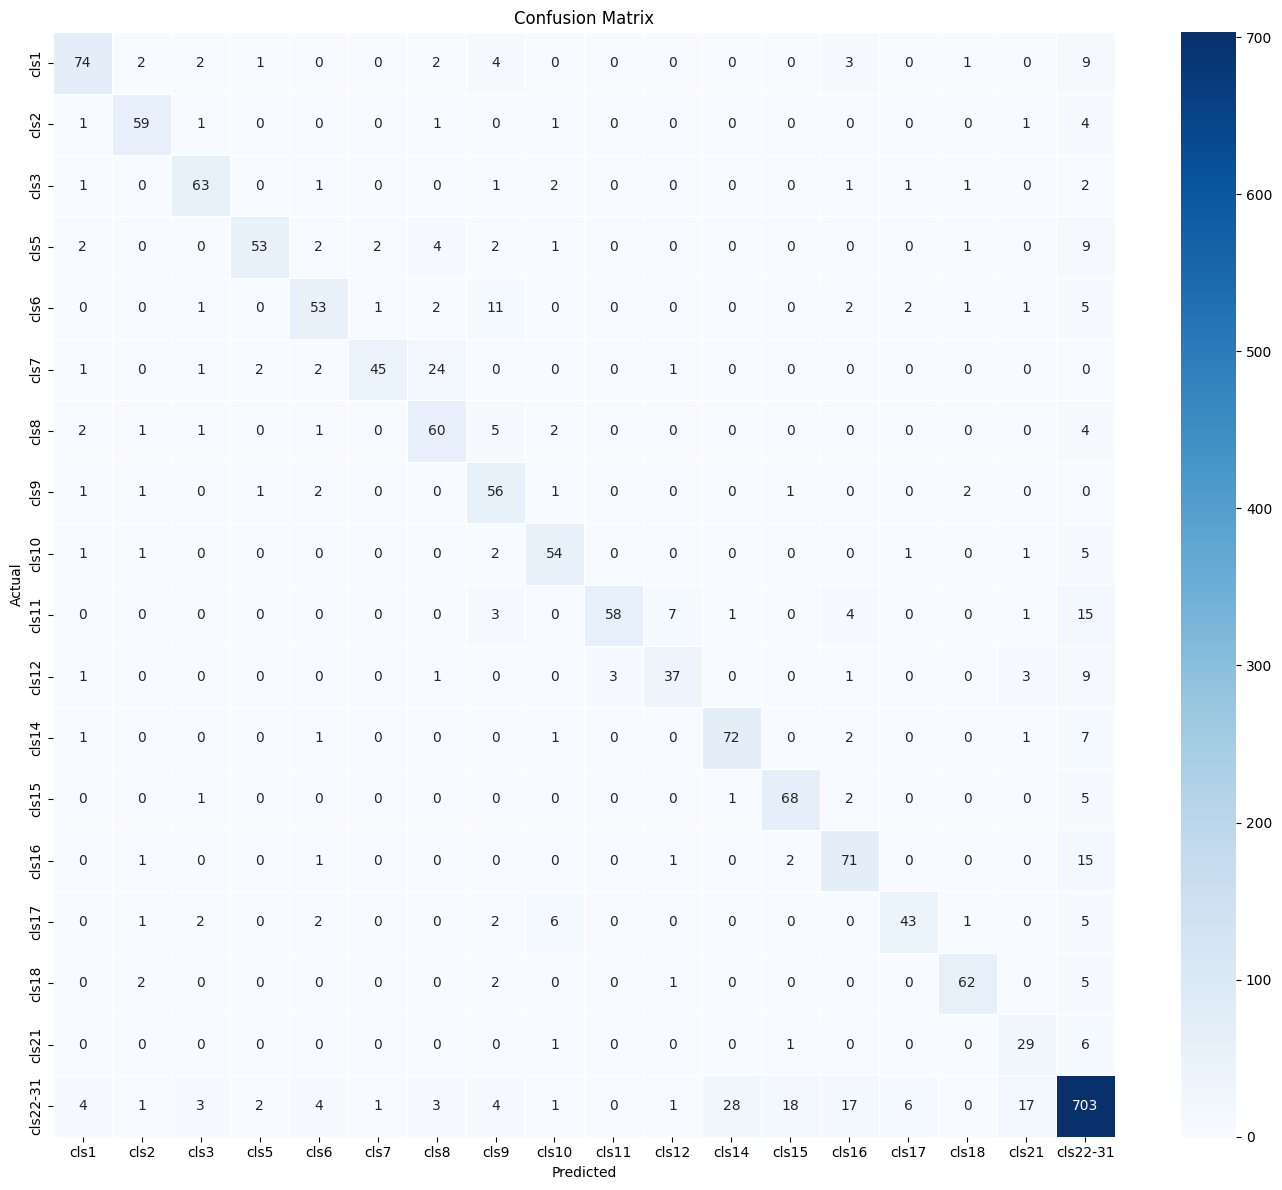

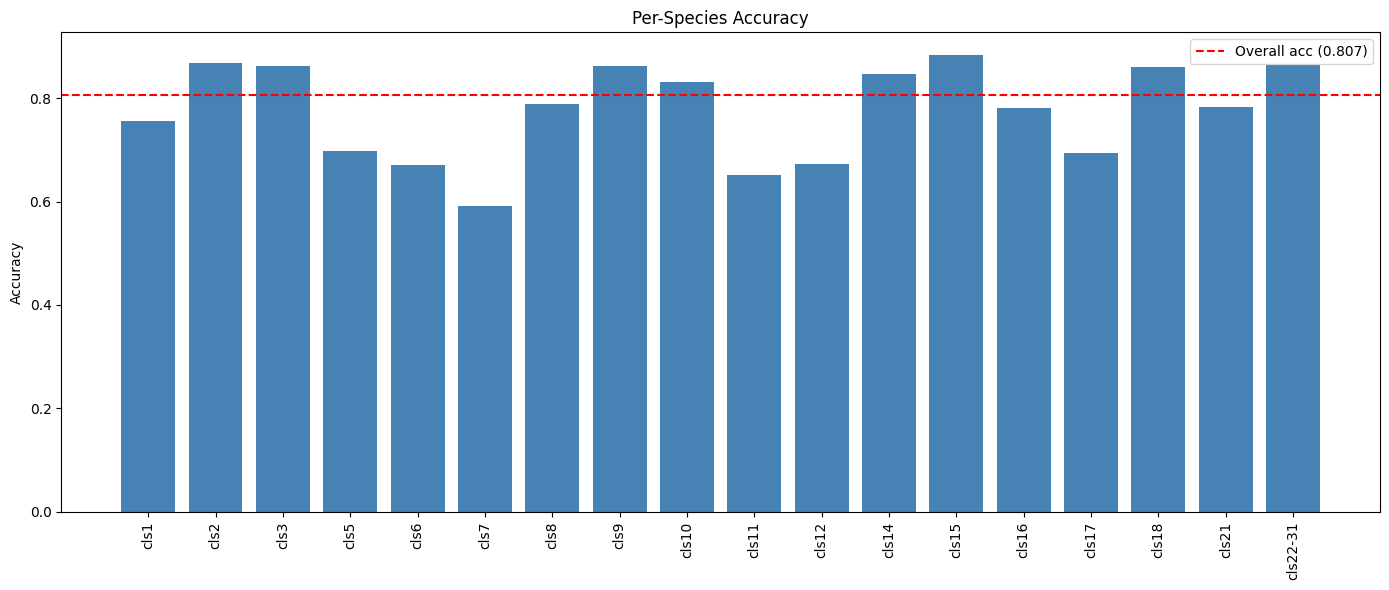

In [17]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from PIL import Image, ImageFile
import timm

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ─── Config ─────────────────────────────────────────────────────────────────
DATASET_ROOT = "dataset"          # adjust if needed
CHECKPOINT   = "best_flat_2.pt"
IMAGE_SIZE   = 224
BATCH_SIZE   = 64
NUM_WORKERS  = 8
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── Label mapping (mirrors CustomGroupedDataset) ────────────────────────────
# original folder-id  → new label
# 1-3                → 0-2
# 5-18               → 3-16   (class_id - 2)
# 21                 → 17
# 22-31              → 18     (all grouped)

def _build_class_names():
    """
    Returns a list indexed by new_label (0 … 18) whose values describe
    which original class-ID(s) the label corresponds to.
    """
    names = {}
    for cid in range(1, 4):          # 1, 2, 3
        names[cid - 1] = f"cls{cid}"
    for cid in range(5, 19):         # 5 … 18
        names[cid - 2] = f"cls{cid}"
    names[17] = "cls21"
    names[18] = "cls22-31"
    return [names[i] for i in range(19)]

ALL_CLASS_NAMES = _build_class_names()   # 19 names, labels 0-18


# ─── Dataset (same remapping as training) ────────────────────────────────────
class CustomGroupedDataset(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)

        new_samples, new_targets = [], []
        for path, _ in self.samples:
            folder_name = path.split(os.sep)[-2]
            class_id = int(folder_name.split(".")[0])

            if 1 <= class_id <= 3:
                new_label = class_id - 1
            elif 5 <= class_id <= 18:
                new_label = class_id - 2
            elif class_id == 21:
                new_label = 17
            elif 22 <= class_id <= 31:
                new_label = 18
            else:
                continue

            new_samples.append((path, new_label))
            new_targets.append(new_label)

        self.samples = new_samples
        self.targets = new_targets
        # classes list aligned with ALL_CLASS_NAMES
        self.classes = ALL_CLASS_NAMES


# ─── Evaluate ────────────────────────────────────────────────────────────────
def evaluate(model, loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    # ── Only use labels that actually appear in this split ──────────────────
    present_labels = sorted(set(y_true.tolist()) | set(y_pred.tolist()))
    present_names  = [class_names[i] for i in present_labels]

    # ── Overall metrics ─────────────────────────────────────────────────────
    overall_acc  = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    kappa        = cohen_kappa_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", labels=present_labels, zero_division=0
    )
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", labels=present_labels, zero_division=0
    )

    # ── Per-class metrics ────────────────────────────────────────────────────
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=present_labels, average=None, zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=present_labels)
    correct = np.diag(cm)
    total   = cm.sum(axis=1)
    per_class_acc = np.divide(
        correct, total,
        out=np.zeros_like(correct, dtype=float),
        where=(total != 0),
    )

    # ── Print per-species table ──────────────────────────────────────────────
    df = pd.DataFrame({
        "Species":   present_names,
        "Acc":       np.round(per_class_acc, 4),
        "Precision": np.round(precision,     4),
        "Recall":    np.round(recall,        4),
        "F1":        np.round(f1,            4),
        "Correct":   correct,
        "Total":     total,
    })

    print("\n" + "=" * 80)
    print("TEST RESULTS — per species")
    print("=" * 80)
    print(df.to_string(index=False))

    # ── Print aggregate metrics ──────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("AGGREGATE METRICS")
    print("=" * 80)
    print(f"{'Metric':<30}{'Macro':>10}{'Weighted':>12}")
    print("-" * 52)
    print(f"{'Precision':<30}{p_macro:>10.4f}{p_weight:>12.4f}")
    print(f"{'Recall':<30}{r_macro:>10.4f}{r_weight:>12.4f}")
    print(f"{'F1 Score':<30}{f1_macro:>10.4f}{f1_weight:>12.4f}")
    print("-" * 52)
    print(f"{'Overall Accuracy':<30}{overall_acc:.4f}")
    print(f"{'Balanced Accuracy':<30}{balanced_acc:.4f}")
    print(f"{'Cohen Kappa':<30}{kappa:.4f}")
    print(f"{'Matthews Corr Coef (MCC)':<30}{mcc:.4f}")

    # ── Full sklearn report ──────────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("FULL CLASSIFICATION REPORT")
    print("=" * 80)
    print(classification_report(
        y_true, y_pred,
        labels=present_labels,
        target_names=present_names,
        zero_division=0,
    ))

    # ── Confusion matrix heatmap ─────────────────────────────────────────────
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=present_names,
        yticklabels=present_names,
        annot=True,
        fmt="d",
        linewidths=0.5,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    print("\nConfusion matrix saved → confusion_matrix.png")

    # ── Per-species accuracy bar chart ───────────────────────────────────────
    plt.figure(figsize=(14, 6))
    bars = plt.bar(present_names, per_class_acc, color="steelblue")
    plt.axhline(overall_acc, color="red", linestyle="--", label=f"Overall acc ({overall_acc:.3f})")
    plt.xticks(rotation=90)
    plt.ylabel("Accuracy")
    plt.title("Per-Species Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig("per_species_accuracy.png", dpi=150)
    print("Per-species accuracy chart saved → per_species_accuracy.png")

    return overall_acc, cm


# ─── Main ────────────────────────────────────────────────────────────────────
def main():
    print(f"Using device: {DEVICE}")

    # ── Data ──────────────────────────────────────────────────────────────────
    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
    ])

    test_dataset = CustomGroupedDataset(
        os.path.join(DATASET_ROOT, "test"),
        transform=val_transform,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    # ── Model ─────────────────────────────────────────────────────────────────
    model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=21)
    model = model.to(DEVICE)

    # ── Load BEST checkpoint (fix: was using last-epoch weights before) ────────
    if not os.path.exists(CHECKPOINT):
        raise FileNotFoundError(
            f"Checkpoint '{CHECKPOINT}' not found. "
            "Make sure best_flat_2.pt is in the working directory."
        )

    ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded checkpoint from epoch {ckpt.get('epoch', '?')} "
          f"(val_acc = {ckpt.get('best_val_acc', '?'):.4f})")

    # ── Evaluate ──────────────────────────────────────────────────────────────
    class_names = test_dataset.classes   # aligned with actual label mapping
    acc, cm = evaluate(model, test_loader, class_names, DEVICE)
    print(f"\nFINAL TEST ACCURACY: {acc:.4f}")


if __name__ == "__main__":
    main()